In [2]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-05.parquet')

In [3]:
df.shape

(4591845, 20)

In [4]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1907210,2,2025-05-17 17:15:26,2025-05-17 18:12:04,2.0,17.44,2.0,N,132,68,1,70.0,0.00,0.5,10.0,6.94,1.0,93.44,2.5,1.75,0.75
1964324,1,2025-05-18 02:38:54,2025-05-18 02:43:21,1.0,0.60,1.0,N,231,231,1,5.8,4.25,0.5,2.3,0.00,1.0,13.85,2.5,0.00,0.75
257326,2,2025-05-03 03:08:17,2025-05-03 03:08:22,1.0,0.00,5.0,N,144,144,1,19.9,0.00,0.0,1.0,0.00,1.0,25.15,2.5,0.00,0.75


In [5]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1196176
trip_distance                  0
RatecodeID               1196176
store_and_fwd_flag       1196176
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1196176
Airport_fee              1196176
cbd_congestion_fee             0
dtype: int64

In [6]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [7]:
df[df.duplicated()].shape

(0, 20)

In [8]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-05-01') | (df["tpep_pickup_datetime"] >= '2025-06-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
7,2,2025-04-30 23:50:34,2025-04-30 23:56:06,2.0,0.99,1.0,N,234,79,1,7.90,1.0,0.5,2.73,0.00,1.0,16.38,2.5,0.0,0.75
9,7,2025-05-01 00:22:31,2025-05-01 00:22:31,1.0,1.09,1.0,N,229,43,1,8.60,0.0,0.5,2.87,0.00,1.0,17.22,2.5,0.0,0.75
15,7,2025-05-01 00:01:22,2025-05-01 00:01:22,1.0,5.01,1.0,N,148,142,1,19.80,0.0,0.5,6.39,0.00,1.0,31.94,2.5,0.0,0.75
16,7,2025-05-01 00:43:04,2025-05-01 00:43:04,1.0,5.72,1.0,N,230,52,1,22.60,0.0,0.5,5.67,0.00,1.0,34.02,2.5,0.0,0.75
60,7,2025-05-01 00:16:34,2025-05-01 00:16:34,1.0,7.20,1.0,N,113,24,1,35.90,0.0,0.5,14.00,0.00,1.0,55.65,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4523849,6,2025-05-30 13:05:39,2025-05-30 13:05:33,NaN,5.66,NaN,None,162,129,0,2.90,0.0,0.5,0.00,0.00,0.3,26.09,NaN,NaN,0.00
4524020,6,2025-05-30 13:05:58,2025-05-30 13:05:54,NaN,1.88,NaN,None,71,72,0,2.90,0.0,0.5,0.00,0.00,0.3,16.00,NaN,NaN,0.00
4529073,6,2025-05-30 16:05:50,2025-05-30 16:05:35,NaN,11.66,NaN,None,51,41,0,1.45,0.0,0.5,0.00,6.94,0.3,55.55,NaN,NaN,0.00
4566059,6,2025-05-31 13:05:01,2025-05-31 13:05:00,NaN,1.59,NaN,None,124,124,0,2.90,0.0,0.5,0.00,0.00,0.3,16.00,NaN,NaN,0.00


In [9]:
# проблемных строк 62774, в 2 раза больше, чем было в апреле, и в 3 раза, чем в марте
# 62774 записи составляют ~1.36% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [10]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [11]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
130,2,2025-05-01 00:52:39,2025-05-01 00:56:44,4.0,0.59,1.0,N,264,148,1,5.80,1.00,0.5,2.31,0.00,1.0,13.86,2.5,0.0,0.75
1614,1,2025-05-01 00:17:42,2025-05-01 00:25:39,2.0,1.40,1.0,N,264,264,1,10.00,4.25,0.5,3.90,0.00,1.0,19.65,2.5,0.0,0.75
3774,2,2025-05-01 02:05:41,2025-05-01 02:48:49,2.0,18.06,2.0,N,264,163,1,70.00,0.00,0.5,10.00,0.00,1.0,84.75,2.5,0.0,0.75
4300,1,2025-05-01 04:22:59,2025-05-01 04:34:03,1.0,3.40,1.0,N,264,231,1,16.30,5.75,0.5,0.00,0.00,1.0,23.55,2.5,0.0,0.75
4554,2,2025-05-01 05:18:46,2025-05-01 05:55:31,1.0,18.60,2.0,N,264,132,2,70.00,0.00,0.5,0.00,6.94,1.0,78.44,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4582102,1,2025-05-31 21:19:20,2025-05-31 21:27:15,NaN,1.90,NaN,None,264,264,0,11.40,1.00,0.5,1.64,0.00,1.0,18.04,NaN,NaN,0.00
4583228,2,2025-05-31 22:20:18,2025-05-31 22:39:12,NaN,0.00,NaN,None,264,264,0,11.98,0.00,0.5,0.00,0.00,1.0,15.98,NaN,NaN,0.00
4584312,2,2025-05-31 22:40:28,2025-05-31 22:55:35,NaN,0.00,NaN,None,264,264,0,12.43,0.00,0.5,0.00,0.00,1.0,16.43,NaN,NaN,0.00
4587899,1,2025-05-31 23:32:43,2025-05-31 23:45:20,NaN,2.60,NaN,None,264,236,0,15.60,1.00,0.5,3.20,0.00,1.0,24.55,NaN,NaN,0.75


In [12]:
# записей с зоной 264 всего 7577
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [13]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4591845-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 70351
осталось записей о поездке: 4521494
максимальная и минимальная даты в таблице: 2025-05-31 23:59:58 2025-05-01 00:00:00


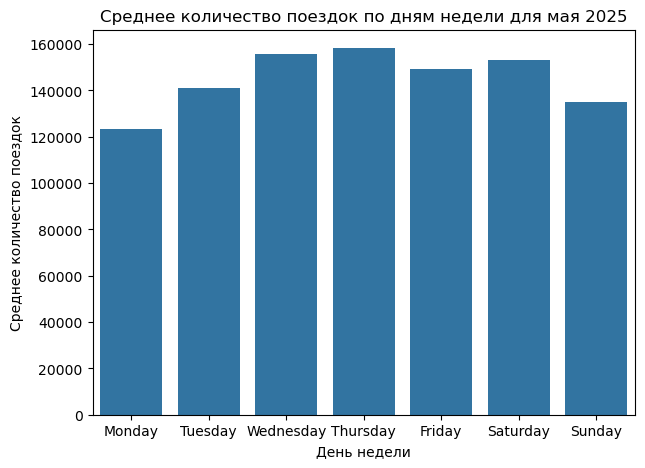

In [14]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для мая 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

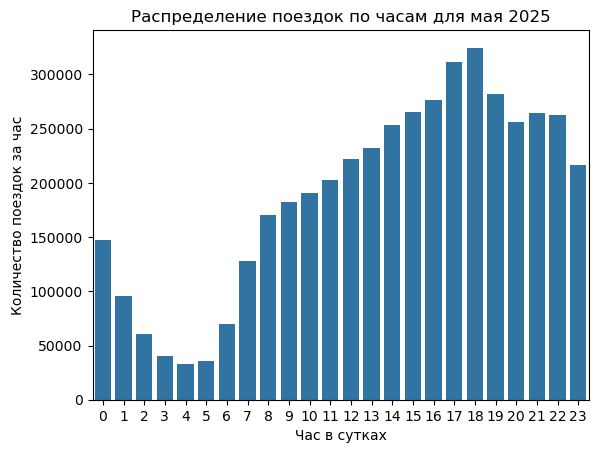

In [15]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для мая 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

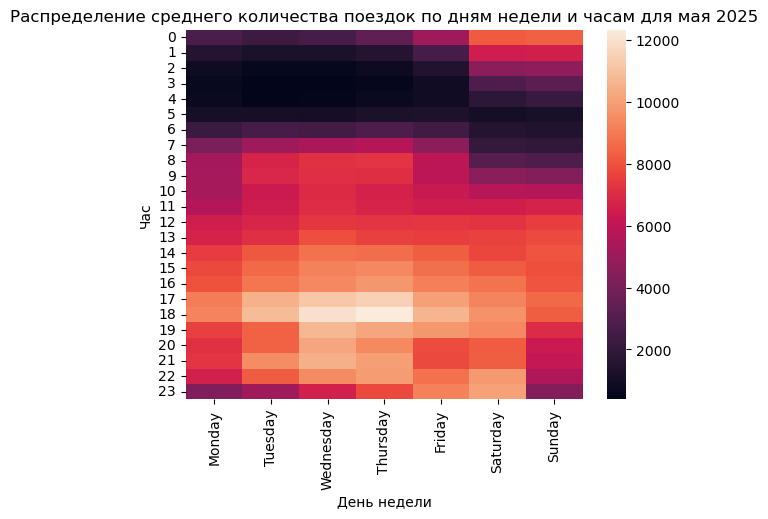

In [16]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для мая 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [17]:
# Графики распределений не имеют значимых отличий от апрельских, пик активности тот же - четверг в 18 ч.

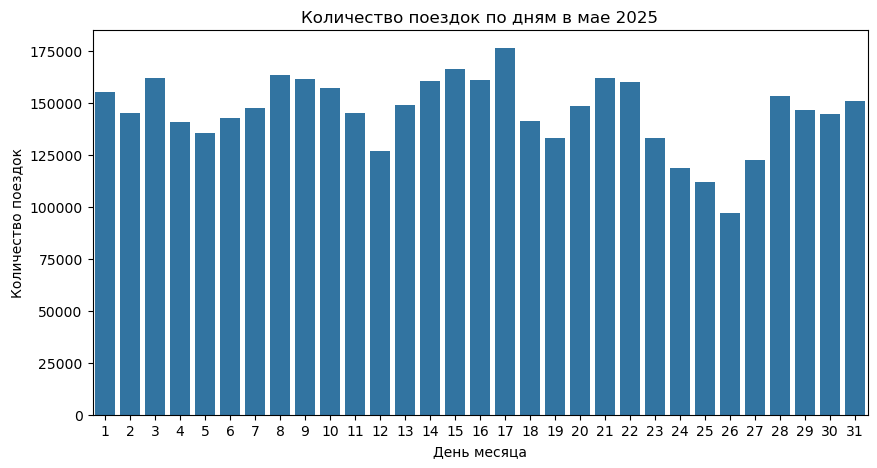

In [18]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в мае 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Паттерн прошлых месяцев сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 5, 12, 19, 26 числа.
# Особенно сильное падение было 26 мая.

In [23]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,502
EWR,532
Bronx,38592
Brooklyn,180770
Queens,450655
Manhattan,3848353


In [20]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-05-01,0,79,103
1,2025-05-01,0,161,91
2,2025-05-01,0,163,76
3,2025-05-01,0,186,87
4,2025-05-01,0,239,22
...,...,...,...,...
3715,2025-05-31,23,79,713
3716,2025-05-31,23,161,271
3717,2025-05-31,23,163,207
3718,2025-05-31,23,186,197


In [ ]:
# В таблице должно быть 31 день x 24 часа x 5 зон = 3720 записей, так и есть. Ничего дополнять не надо.

In [21]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_05.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [22]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3720, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
